# Lecture 5 — Look at your data (EDA)

**Companion notebook for Frankfurt UAS · Machine Learning · Lecture 5 of 10**

In V4 we modeled — but we never asked: *is this data even sensible?* Today we catch up.
**Exploratory Data Analysis** is the first thing you do with any new dataset.

This notebook walks through eight EDA steps on a Titanic-style passenger dataset.
The data is generated synthetically (so it works offline) but mirrors the structure
of real passenger survey data: missing values, outliers, categorical features,
and realistic survival patterns.

Run cells top-to-bottom alongside the slides.

---

## Section 1 — Load the data

We generate a Titanic-style dataset with all the EDA-relevant phenomena baked in.
In a real project you would `pd.read_csv(...)` instead — the rest of the notebook is the same.

In [2]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.dpi'] = 100
np.random.seed(42)
sns.set_style("whitegrid")

print("All imports OK.")

All imports OK.


In [24]:
import seaborn as sns
df = sns.load_dataset("titanic")

---

## Section 2 — The first look

**Step 1 — orient yourself in the data.** These six commands are non-negotiable:
run them on every new dataset, every single time.

In [25]:
# How big is the dataset?
print("Shape:", df.shape)
print("That's", df.shape[0], "rows and", df.shape[1], "columns.")

Shape: (891, 15)
That's 891 rows and 15 columns.


In [35]:
# What does it look like?
df.head(100)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0,3,male,NaN,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
96,0,1,male,71.0,0,0,34.6542,C,First,man,True,A,Cherbourg,no,True
97,1,1,male,23.0,0,1,63.3583,C,First,man,True,D,Cherbourg,yes,False
98,1,2,female,34.0,0,1,23.0000,S,Second,woman,False,NaN,Southampton,yes,False


In [27]:
# What about the bottom — anything weird?
df.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


In [28]:
# Types and non-null counts in one go
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


**Read the output carefully:**
- `age` has fewer non-null entries than the 891 total → missing values
- `embarked` also has a few missing
- Mix of types: int64 (counts), float64 (continuous), object (strings)

In [29]:
# Numeric summary statistics — one row of stats per column
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**What does each row tell us?**

- **count** below 891 = missing values present (here: age)
- **mean & std** show the center and spread
- **min/25%/50%/75%/max** show the distribution shape
- Look for sanity: age max = 80 (reasonable). fare max — high? Long tail!

> Notice `fare` has mean ~50 but max far above 75th percentile = **long tail / outliers**.
> We'll come back to this in section 3.

---

## Section 3 — Distributions

**Step 2 — see the shape of each numeric feature.** Histograms tell you the *form*
of a distribution. Box plots make outliers visible.

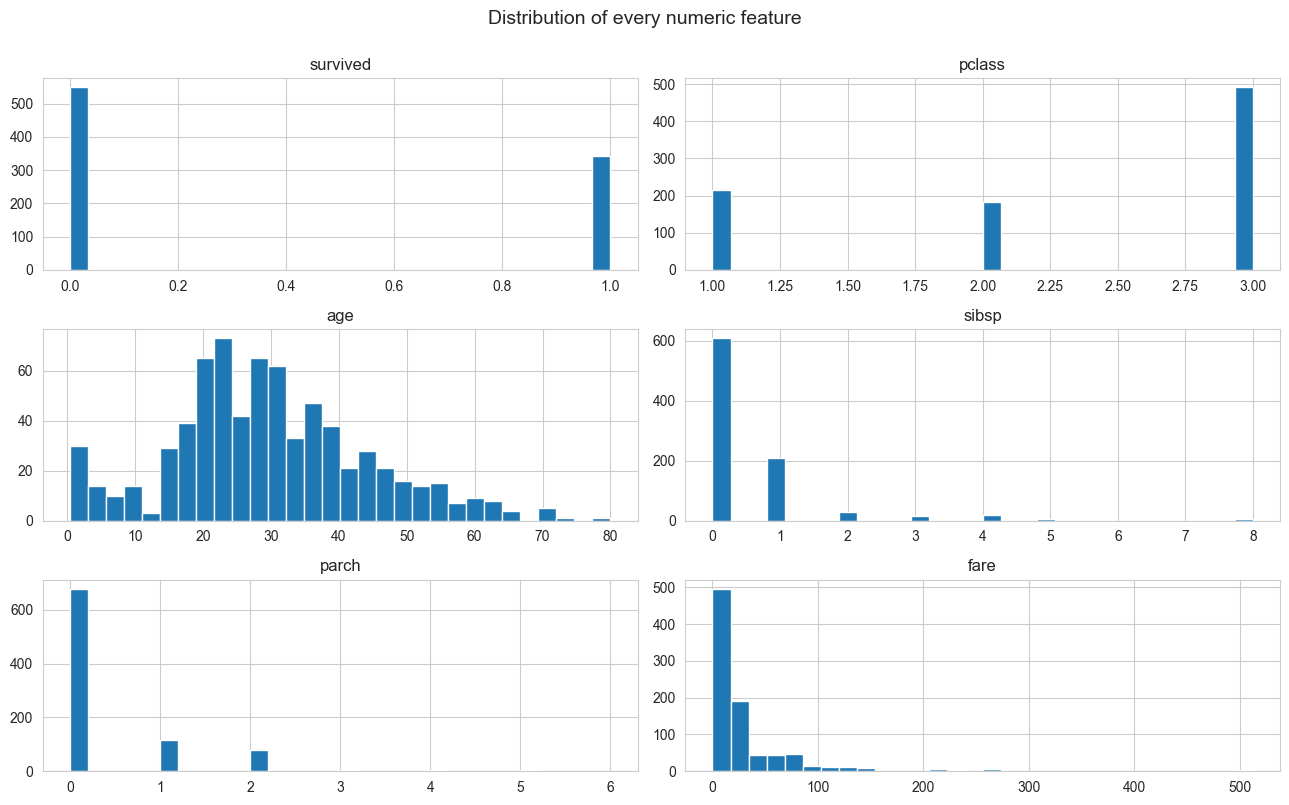

In [31]:
# Histograms for all numeric columns at once
df.hist(figsize=(13, 8), bins=30, edgecolor="white")
plt.suptitle("Distribution of every numeric feature", fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

**What to look for in those histograms:**
- **age** — roughly bell-shaped, but a peak near 0 hints at children
- **fare** — heavy right skew (long tail of expensive tickets)
- **sibsp, parch** — most passengers travel alone (mode at 0)
- **pclass** — 1, 2, 3 — discrete, looks fine
- **survived** — binary, slight imbalance (more 0s than 1s)

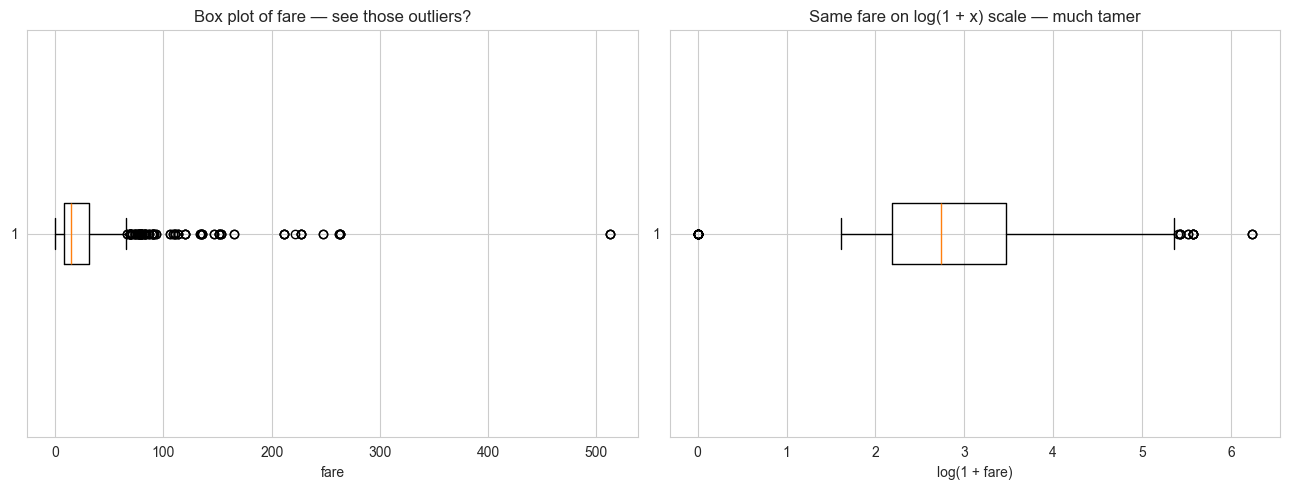

In [32]:
# Box plot for fare — the outlier-suspect feature
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].boxplot(df["fare"].dropna(), vert=False)
axes[0].set_title("Box plot of fare — see those outliers?")
axes[0].set_xlabel("fare")

# Same data, but log scale — outliers compressed
axes[1].boxplot(np.log1p(df["fare"].dropna()), vert=False)
axes[1].set_title("Same fare on log(1 + x) scale — much tamer")
axes[1].set_xlabel("log(1 + fare)")

plt.tight_layout()
plt.show()

The dots beyond the whiskers are flagged as outliers by pandas/matplotlib.
But *are they real outliers?* Some are. First-class tickets really did cost much more.
**Outliers aren't always errors — investigate before deleting.**

A common fix in modeling: take `log(1 + fare)` instead of raw fare. That compresses
the tail and makes the distribution more model-friendly. (V6 territory.)

---

## Section 4 — Categorical features

For categorical features, distributions don't make sense. Use `value_counts()` instead.

In [11]:
# How many of each category?
print("=== sex ===")
print(df["sex"].value_counts())
print()
print("=== pclass ===")
print(df["pclass"].value_counts())
print()
print("=== embarked ===")
print(df["embarked"].value_counts(dropna=False))  # show NaN too

=== sex ===
sex
male      571
female    320
Name: count, dtype: int64

=== pclass ===
pclass
3    492
1    224
2    175
Name: count, dtype: int64

=== embarked ===
embarked
S      641
C      160
Q       86
NaN      4
Name: count, dtype: int64


In [12]:
# Same info, as percentages
print("Sex distribution:")
print(df["sex"].value_counts(normalize=True).round(3))

Sex distribution:
sex
male      0.641
female    0.359
Name: proportion, dtype: float64


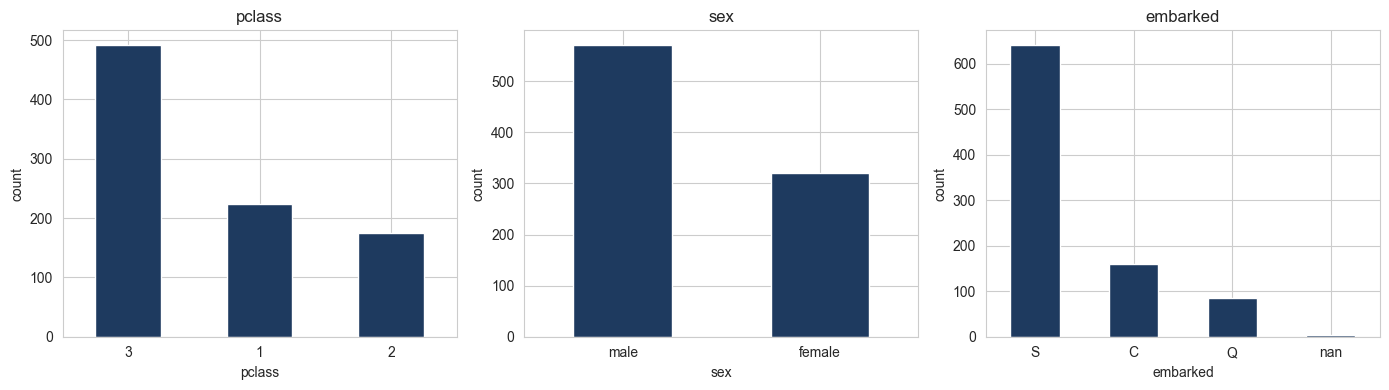

In [13]:
# Visualize all three categorical features side-by-side
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["pclass", "sex", "embarked"]):
    df[col].value_counts(dropna=False).plot.bar(ax=ax, color="#1E3A5F")
    ax.set_title(f"{col}")
    ax.set_ylabel("count")
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

**What to read off these bars:**
- More third-class passengers than first or second
- More males than females (typical of the era)
- Most embarked at Southampton (S)

> **Class imbalance check:** None of these are extreme (no category has 99%).
> But always run this — imbalance affects modeling.

---

## Section 5 — Missing data

**Step 3 — where is the data missing, and how much?**

In [14]:
# Counts of missing values per column
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Fraction missing per column:")
print((df.isnull().mean() * 100).round(2).astype(str) + " %")

Missing values per column:
pclass        0
sex           0
age         194
fare          0
sibsp         0
parch         0
embarked      4
survived      0
dtype: int64

Fraction missing per column:
pclass        0.0 %
sex           0.0 %
age         21.77 %
fare          0.0 %
sibsp         0.0 %
parch         0.0 %
embarked     0.45 %
survived      0.0 %
dtype: str


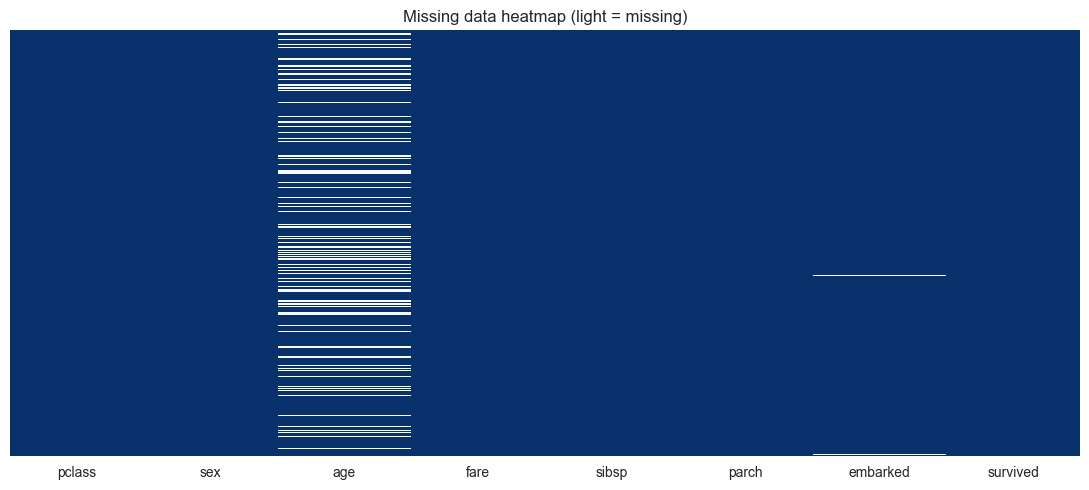

In [15]:
# Visual pattern of missing data — one row per passenger, white = missing
fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="Blues_r", ax=ax)
ax.set_title("Missing data heatmap (light = missing)")
plt.tight_layout()
plt.show()

**Read the heatmap:**
- Vertical stripes for **age** = scattered missingness, distributed throughout the data
- A few specks for **embarked** = rare, can probably drop those rows

If you saw *blocks* of missing data (clustered in particular rows or columns), that
would be a different signal — possibly systematic, not random.

> **What to do about missing data is V6.** Today we just *find* it.

In [ ]:
from sklearn.impute import SimpleImputer

# Make a working copy so we can compare before/after
df_imputed = df.copy()

# Create the imputer with strategy="median"
imputer = SimpleImputer(strategy="median")

# Fit on the age column and replace missing values
df_imputed[["age"]] = imputer.fit_transform(df[["age"]])

print(f"Median age used for imputation: {imputer.statistics_[0]:.1f}")
print()
print("Before:", df["age"].isnull().sum(), "missing values in age")
print("After: ", df_imputed["age"].isnull().sum(), "missing values in age")

Median age used for imputation: 28.0

Before: 177 missing values in age
After:  0 missing values in age


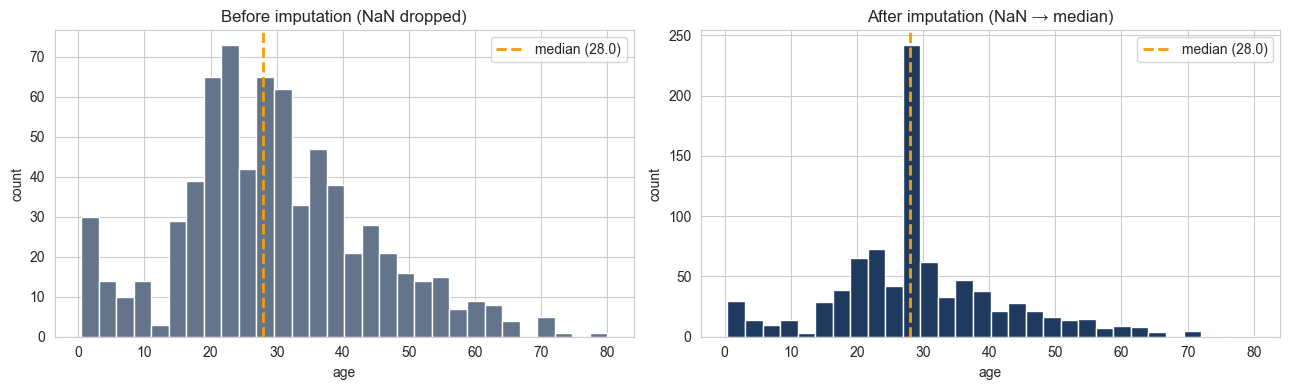

In [34]:
# Compare distributions before and after imputation
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Before
axes[0].hist(df["age"].dropna(), bins=30, edgecolor="white", color="#64748B")
axes[0].axvline(imputer.statistics_[0], color="#F59E0B", linestyle="--",
                linewidth=2, label=f"median ({imputer.statistics_[0]:.1f})")
axes[0].set_title("Before imputation (NaN dropped)")
axes[0].set_xlabel("age")
axes[0].set_ylabel("count")
axes[0].legend()

# After
axes[1].hist(df_imputed["age"], bins=30, edgecolor="white", color="#1E3A5F")
axes[1].axvline(imputer.statistics_[0], color="#F59E0B", linestyle="--",
                linewidth=2, label=f"median ({imputer.statistics_[0]:.1f})")
axes[1].set_title("After imputation (NaN → median)")
axes[1].set_xlabel("age")
axes[1].set_ylabel("count")
axes[1].legend()

plt.tight_layout()
plt.show()

In [39]:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


---

## Section 6 — Relationships

**Step 4 — how do features relate to each other?** Correlation matrix gives a 30-second
overview of all pairwise linear relationships.

In [16]:
# Correlation matrix for numeric features
corr = df.corr(numeric_only=True)
print(corr.round(2))

          pclass   age  fare  sibsp  parch  survived
pclass      1.00 -0.06 -0.64   0.04  -0.10     -0.26
age        -0.06  1.00 -0.03   0.06  -0.01     -0.07
fare       -0.64 -0.03  1.00  -0.05   0.10      0.17
sibsp       0.04  0.06 -0.05   1.00  -0.02     -0.05
parch      -0.10 -0.01  0.10  -0.02   1.00      0.08
survived   -0.26 -0.07  0.17  -0.05   0.08      1.00


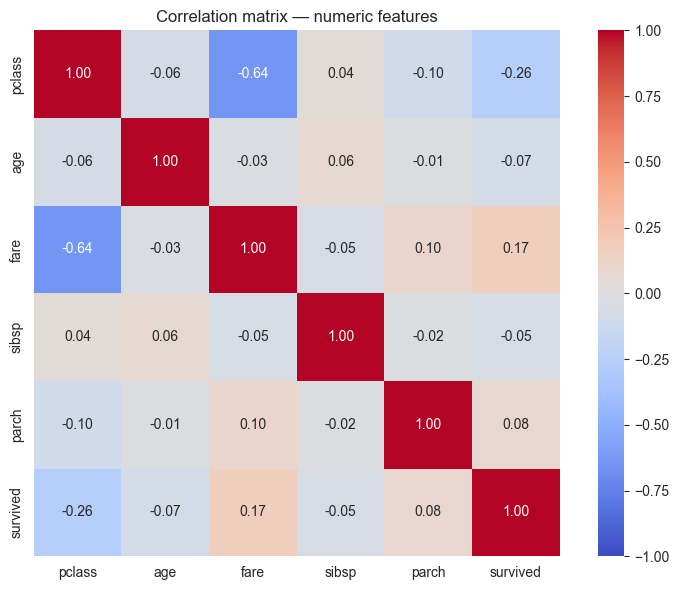

In [17]:
# Visualize as heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("Correlation matrix — numeric features")
plt.tight_layout()
plt.show()

**What to look for in a correlation heatmap:**

- **Strong correlations between features (high abs values not on the diagonal):**
  redundant information. Two features that move together don't add much over each other.
  Here: `pclass` and `fare` — naturally correlated (first-class costs more).

- **Strong correlations with the target (last row/column):**
  predictive power! Features that correlate with `survived` are useful for modeling.
  Here: `pclass` correlates negatively with survival (higher class number = lower survival).

- **Zero correlations are also informative:**
  could mean truly unrelated, OR a non-linear relationship that linear correlation misses.
  Always combine with scatter plots for confirmation.

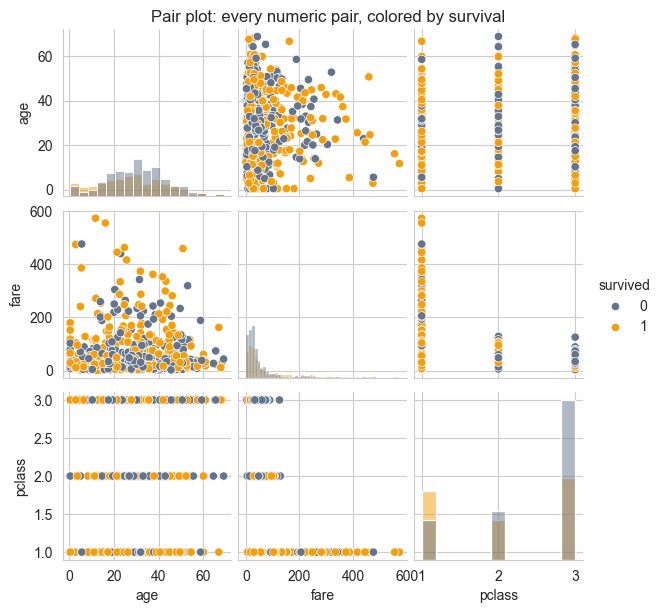

In [18]:
# Pair plot — scatters for every pair, colored by target
# (Limit to a few features so it stays readable)
sample_cols = ["age", "fare", "pclass", "survived"]
sns.pairplot(df[sample_cols].dropna(), hue="survived",
             palette={0: "#64748B", 1: "#F59E0B"}, diag_kind="hist",
             height=2)
plt.suptitle("Pair plot: every numeric pair, colored by survival", y=1.01)
plt.show()

Pair plots are slower than correlation matrices but show *actual* shapes — which is
useful when correlations are zero but the relationship is non-linear (e.g. U-shaped).

---

## Section 7 — Where's the signal?

**The most important EDA question:** does each feature differ between target classes?
If yes, your model has something to learn from it.

In [19]:
# Survival rate by sex
print("=== Survival rate by sex ===")
print(df.groupby("sex")["survived"].mean().round(3))
print()
print("=== Survival rate by pclass ===")
print(df.groupby("pclass")["survived"].mean().round(3))
print()
print("=== Survival rate by embarked port ===")
print(df.groupby("embarked")["survived"].mean().round(3))

=== Survival rate by sex ===
sex
female    0.784
male      0.235
Name: survived, dtype: float64

=== Survival rate by pclass ===
pclass
1    0.634
2    0.474
3    0.325
Name: survived, dtype: float64

=== Survival rate by embarked port ===
embarked
C    0.406
Q    0.349
S    0.449
Name: survived, dtype: float64


**These three numbers are gold.** Strong signal: sex matters massively (women
survive at much higher rates), class matters too (first-class >> third-class).

If a feature gave the *same* survival rate across all categories, it would be useless
for prediction. EDA reveals predictive features before you ever train.

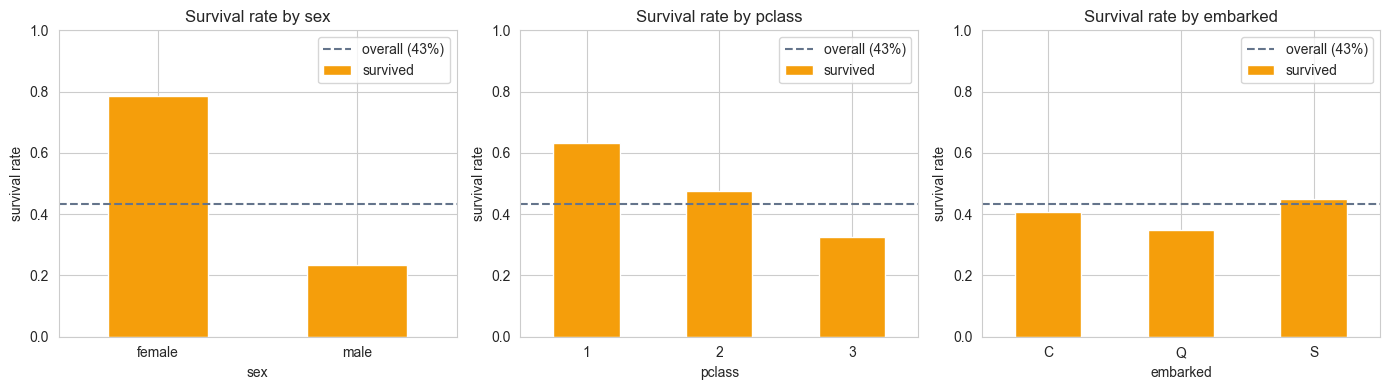

In [20]:
# Visualize the same — bar charts of survival rate
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, ["sex", "pclass", "embarked"]):
    rates = df.groupby(col)["survived"].mean()
    rates.plot.bar(ax=ax, color="#F59E0B")
    ax.set_title(f"Survival rate by {col}")
    ax.set_ylabel("survival rate")
    ax.set_ylim(0, 1)
    ax.axhline(df["survived"].mean(), color="#64748B", linestyle="--",
               label=f"overall ({df['survived'].mean():.0%})")
    ax.legend()
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

/var/folders/r0/nz47j5qs2wlcz2b0shdjx1tr0000gn/T/ipykernel_65653/3012398650.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="survived", y="age", ax=axes[0],
/var/folders/r0/nz47j5qs2wlcz2b0shdjx1tr0000gn/T/ipykernel_65653/3012398650.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x="survived", y="log_fare", ax=axes[1],


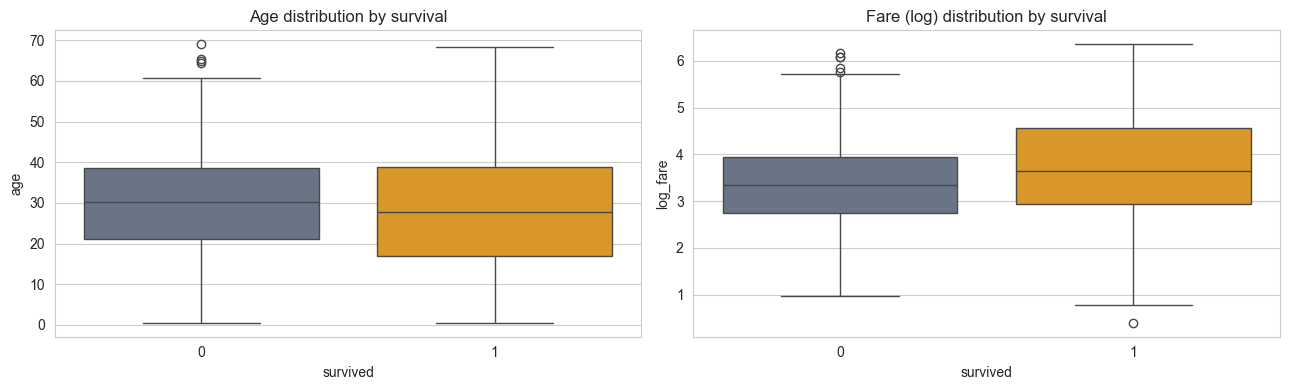

In [21]:
# For numeric features: distribution per class
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Age
sns.boxplot(data=df, x="survived", y="age", ax=axes[0],
            palette=["#64748B", "#F59E0B"])
axes[0].set_title("Age distribution by survival")

# Fare (log scale because of outliers)
df_plot = df.copy()
df_plot["log_fare"] = np.log1p(df_plot["fare"])
sns.boxplot(data=df_plot, x="survived", y="log_fare", ax=axes[1],
            palette=["#64748B", "#F59E0B"])
axes[1].set_title("Fare (log) distribution by survival")

plt.tight_layout()
plt.show()

**Read the box plots:**
- Age boxes overlap mostly — age alone is not a strong signal (children are exception
  but they're a small group)
- Fare boxes are clearly different — survivors paid more on average. Strong signal.

---

## Section 8 — Wrap-up

You've now done a full EDA pass on this dataset. You know:

1. **Size & types:** 891 rows, mix of numeric and categorical
2. **Distributions:** fare is long-tailed; age looks roughly normal
3. **Missing data:** ~20% of ages missing, scattered randomly
4. **Outliers:** fare has them — but they're real (first-class tickets)
5. **Class structure:** more 3rd class, more males
6. **Predictive signal:** sex and pclass matter most, fare moderately, age weakly

> **Now — and only now — would you start modeling.**
> You know what features matter, what to expect from the model,
> and what data quality issues to fix in V6.

---

## Bonus exercises

### Exercise 1 — Family size feature
Create a new feature `family_size = sibsp + parch + 1` (the +1 is for the passenger
themselves). What's the survival rate per family size? Plot it.

In [22]:
# Starter:
df["family_size"] = df["sibsp"] + df["parch"] + 1

# TODO: groupby family_size, compute survival mean, plot
# Hint: there's an interesting U-shape here — alone passengers and large families
# both have lower survival. Why might that be?

### Exercise 2 — Cross-tabs
A pandas `crosstab` shows survival rate broken down by *two* features at once.
This often reveals stronger patterns than either feature alone.

In [23]:
# Starter:
ct = pd.crosstab(df["sex"], df["pclass"], values=df["survived"], aggfunc="mean")
print(ct.round(3))

# TODO: visualize this as a heatmap with sns.heatmap
# What do you see? Is there a "best" combination of features for survival?

pclass      1      2      3
sex                        
female  0.900  0.862  0.709
male    0.486  0.282  0.100


### Exercise 3 — Real data
Apply this whole notebook to a different dataset. Some good options:

- A Kaggle dataset of your choice
- The full Titanic dataset from `seaborn.load_dataset("titanic")` (if you have internet)
- Any CSV file you have laying around

Run the same six steps: shape/info/describe → distributions → missing → categorical →
relationships → target. Write down five things you learned about the data BEFORE
you ever called `fit()`.

---

**Next lecture (V6): Data Preparation.** We've found the issues today —
next time we fix them. Encoding categoricals, imputing missing values, scaling
features, splitting time-series correctly.